# Pylops - sparse vs dense operators

### Author: M.Ravasi

In this notebook I will compare a number of operators that can benefit from sparsification, namely:

- sinc interpolator: default uses all of the points vs. frugal that uses only a limited number of points whose value is above a given threshold
- convmtx/nonstationary_convmtx: dense matrix vs banded sparse matrix

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from pylops.utils import dottest
from pylops.basicoperators import *
from pylops.signalprocessing import *

from pylops.signalprocessing.interp import _sincinterp
from pylops.utils.signalprocessing import convmtx, nonstationary_convmtx

## Sinc

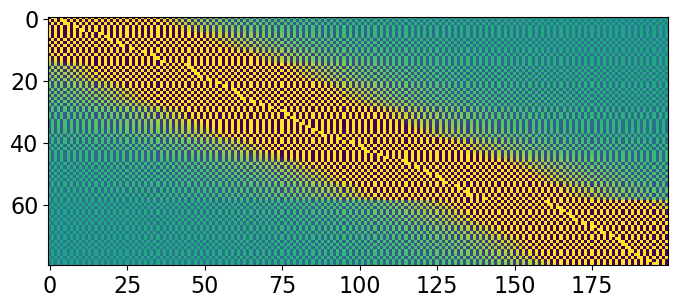

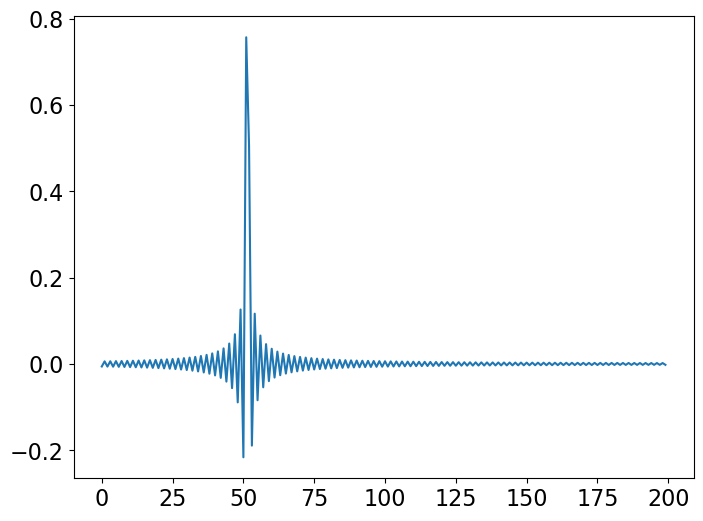

In [2]:
nt = 200
perc_subsampling = 0.4

ntsub = int(np.round(nt*perc_subsampling))
isample = np.arange(nt)
iava = np.sort(np.random.permutation(np.arange(nt))[:ntsub])

dims = (nt,)
axis = 0
iava1 = iava + 0.4

# create sinc interpolation matrix
nreg = dims[axis]
ireg = np.arange(nreg)
sinc = np.tile(iava1[:, np.newaxis], (1, nreg)) - np.tile(ireg, (len(iava), 1))
sinc = np.sinc(sinc)

plt.figure()
plt.imshow(sinc, vmin=-1e-2, vmax=1e-2)

plt.figure()
plt.plot(sinc[20])

11576 16000


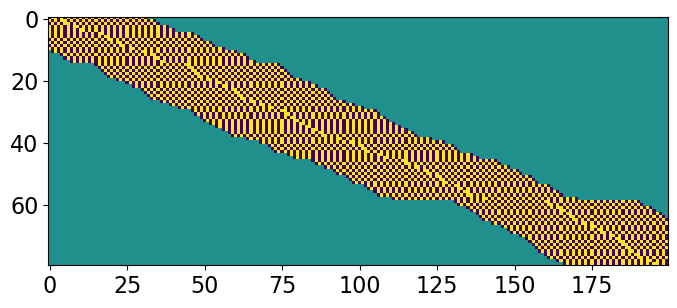

In [3]:
sinc_sparse = sinc.copy()
print(np.sum(np.abs(sinc_sparse) < 1e-2), sinc_sparse.size)
sinc_sparse[np.abs(sinc_sparse) < 1e-2] = 0
sinc_sparse = sp.sparse.csr_matrix(sinc_sparse)

plt.figure()
plt.imshow(sinc_sparse.todense(), vmin=-1e-2, vmax=1e-2)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4457 stored elements and shape (80, 200)>
  Coords	Values
  (0, 0)	0.756826728640657
  (0, 1)	0.5045511524271047
  (0, 2)	-0.18920668216016426
  (0, 3)	0.11643488132933186
  (0, 4)	-0.0840918587378508
  (0, 5)	0.06581101988179631
  (0, 6)	-0.054059052045761224
  (0, 7)	0.045868286584282256
  (0, 8)	-0.03983298571792933
  (0, 9)	0.03520124319258871
  (0, 10)	-0.03153444702669406
  (0, 11)	0.028559499193987106
  (0, 12)	-0.026097473401401977
  (0, 13)	0.024026245353671694
  (0, 14)	-0.022259609665901688
  (0, 15)	0.020734978866867353
  (0, 16)	-0.019405813554888653
  (0, 17)	0.018236788641943533
  (0, 18)	-0.017200607469105813
  (0, 19)	0.01627584362668079
  (0, 20)	-0.015445443441646035
  (0, 21)	0.014695664633799125
  (0, 22)	-0.014015309789641809
  (0, 23)	0.013395163338772687
  (0, 24)	-0.012827571671875525
  :	:
  (79, 175)	0.014839739777267871
  (79, 176)	-0.015604674817333207
  (79, 177)	0.016452754970449162
  (79, 178)

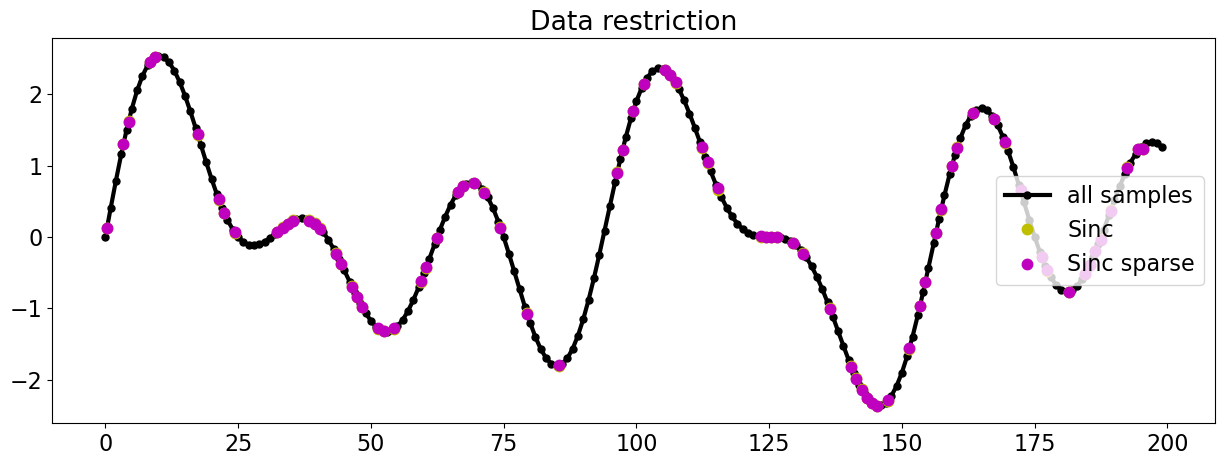

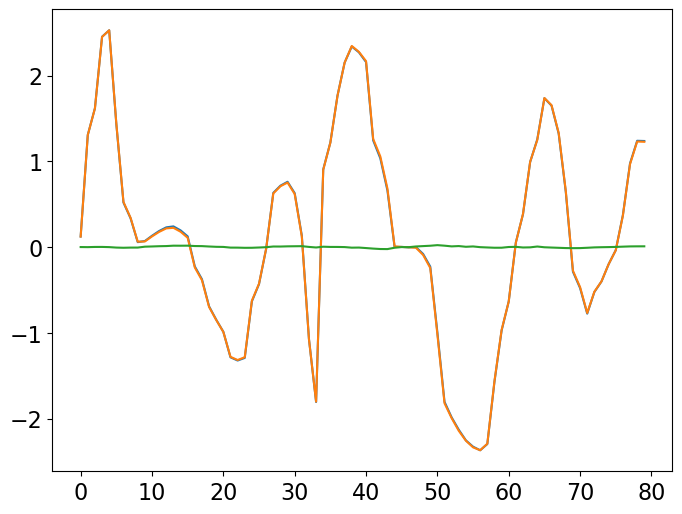

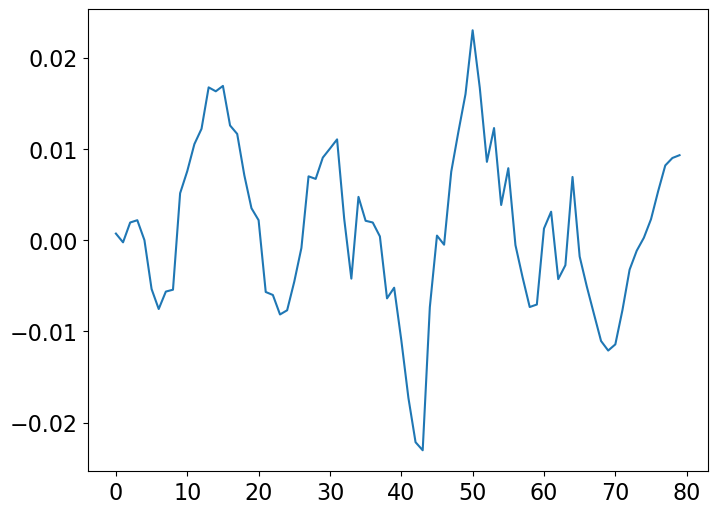

In [4]:
nt = 200
dt = 0.004

freqs = [5., 3., 8.]

t = np.arange(nt)*dt
x = np.zeros(nt)

for freq in freqs:
    x = x + np.sin(2*np.pi*freq*t)

perc_subsampling = 0.4
ntsub = int(np.round(nt*perc_subsampling))

isample = np.arange(nt)
iava = np.sort(np.random.permutation(np.arange(nt))[:ntsub])

SIop, iavasi = Interp(nt, iava + 0.4, kind='sinc', dtype='float64')
SIspop, _ = Interp(nt, iava + 0.4, kind='sinc', tol=1e-2, dtype='float64')
ysi = SIop*x
ysisp = SIspop*x

print(SIspop.A)

# Visualize data
fig = plt.figure(figsize=(15, 5))
plt.plot(isample, x, '.-k', lw=3, ms=10, label='all samples')
plt.plot(iavasi, ysi, '.y', ms=15, label='Sinc')
plt.plot(iavasi, ysisp, '.m', ms=15, label='Sinc sparse')
plt.legend(loc='right')
plt.title('Data restriction');

plt.figure()
plt.plot(ysi)
plt.plot(ysisp)
plt.plot(ysi - ysisp)

plt.figure()
plt.plot(ysi - ysisp);

### Testing speed

In [5]:
nt = 5000
nx = 1000

isample = np.arange(nt)
iava = np.sort(np.random.permutation(np.arange(nt))[:ntsub])
iava1 = iava + 0.4

x = np.ones((nt, nx))
SIop, iavasi = Interp((nt, nx), iava + 0.4, kind='sinc', dtype='float64')
SIspop, _ = Interp((nt, nx), iava + 0.4, kind='sinc', tol=1e-2, dtype='float64')
ysi = SIop*x
ysisp = SIspop*x

In [6]:
%timeit -n 5 -r 4 SIop.matvec(x.ravel())
%timeit -n 5 -r 4 SIspop.matvec(x.ravel())

3.37 ms ± 145 μs per loop (mean ± std. dev. of 4 runs, 5 loops each)
915 μs ± 50.3 μs per loop (mean ± std. dev. of 4 runs, 5 loops each)


In [7]:
%timeit -n 5 -r 4 SIop.rmatvec(ysi.ravel())
%timeit -n 5 -r 4 SIspop.rmatvec(ysi.ravel())

7.42 ms ± 1.54 ms per loop (mean ± std. dev. of 4 runs, 5 loops each)
3.16 ms ± 281 μs per loop (mean ± std. dev. of 4 runs, 5 loops each)


## Convmtx

<DIAgonal sparse matrix of dtype 'float64'
	with 1002 stored elements (5 diagonals) and shape (205, 201)>
  Coords	Values
  (2, 0)	1.0
  (3, 1)	1.0
  (4, 2)	1.0
  (5, 3)	1.0
  (6, 4)	1.0
  (7, 5)	1.0
  (8, 6)	1.0
  (9, 7)	1.0
  (10, 8)	1.0
  (11, 9)	1.0
  (12, 10)	1.0
  (13, 11)	1.0
  (14, 12)	1.0
  (15, 13)	1.0
  (16, 14)	1.0
  (17, 15)	1.0
  (18, 16)	1.0
  (19, 17)	1.0
  (20, 18)	1.0
  (21, 19)	1.0
  (22, 20)	1.0
  (23, 21)	1.0
  (24, 22)	1.0
  (25, 23)	1.0
  (26, 24)	1.0
  :	:
  (174, 176)	1.0
  (175, 177)	1.0
  (176, 178)	1.0
  (177, 179)	1.0
  (178, 180)	1.0
  (179, 181)	1.0
  (180, 182)	1.0
  (181, 183)	1.0
  (182, 184)	1.0
  (183, 185)	1.0
  (184, 186)	1.0
  (185, 187)	1.0
  (186, 188)	1.0
  (187, 189)	1.0
  (188, 190)	1.0
  (189, 191)	1.0
  (190, 192)	1.0
  (191, 193)	1.0
  (192, 194)	1.0
  (193, 195)	1.0
  (194, 196)	1.0
  (195, 197)	1.0
  (196, 198)	1.0
  (197, 199)	1.0
  (198, 200)	1.0


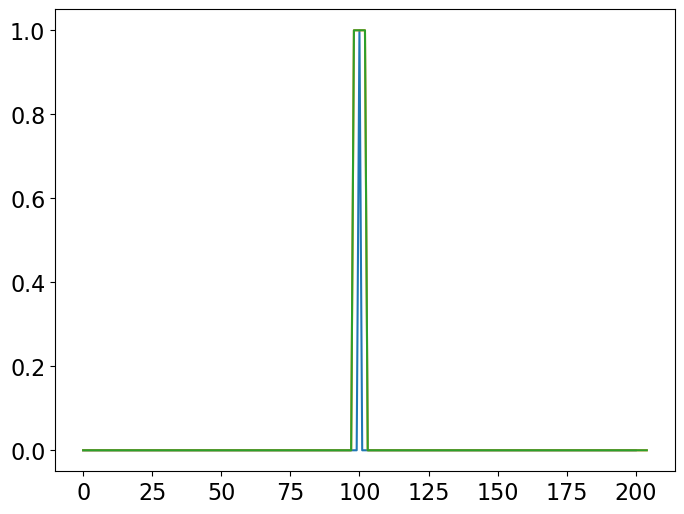

In [8]:
nh, nt = 5, 201
h = np.ones(nh)
H = convmtx(h, nt, offset=nh//2)
Hsp = convmtx(h, nt, offset=nh//2, sparse=True)

print(Hsp)

x = np.zeros(nt)
x[nt//2] = 1

y = H @ x
ysp = Hsp @ x

plt.figure()
plt.plot(x)
plt.plot(y)
plt.plot(ysp);

In [9]:
nh, nt = 5, 10001
h = np.ones(nh)
H = convmtx(h, nt, offset=nh//2)
Hsp = convmtx(h, nt, offset=nh//2, sparse=True)
x = np.zeros(nt)
x[nt//2] = 1

%timeit -n 5 -r 4 H @ x
%timeit -n 5 -r 4 Hsp @ x

The slowest run took 8.01 times longer than the fastest. This could mean that an intermediate result is being cached.
46 ms ± 40.3 ms per loop (mean ± std. dev. of 4 runs, 5 loops each)
The slowest run took 257.37 times longer than the fastest. This could mean that an intermediate result is being cached.
1.07 ms ± 1.82 ms per loop (mean ± std. dev. of 4 runs, 5 loops each)


In [10]:
nh, nt = 25, 10001
h = np.ones(nh)
H = convmtx(h, nt, offset=nh//2)
Hsp = convmtx(h, nt, offset=nh//2, sparse=True)
print(Hsp)

x = np.zeros(nt)
x[nt//2] = 1

%timeit -n 5 -r 4 H @ x
%timeit -n 5 -r 4 Hsp @ x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 249947 stored elements and shape (10025, 10001)>
  Coords	Values
  (0, 0)	1.0
  (0, 1)	1.0
  (0, 2)	1.0
  (0, 3)	1.0
  (0, 4)	1.0
  (0, 5)	1.0
  (0, 6)	1.0
  (0, 7)	1.0
  (0, 8)	1.0
  (0, 9)	1.0
  (0, 10)	1.0
  (0, 11)	1.0
  (0, 12)	1.0
  (1, 0)	1.0
  (1, 1)	1.0
  (1, 2)	1.0
  (1, 3)	1.0
  (1, 4)	1.0
  (1, 5)	1.0
  (1, 6)	1.0
  (1, 7)	1.0
  (1, 8)	1.0
  (1, 9)	1.0
  (1, 10)	1.0
  (1, 11)	1.0
  :	:
  (10006, 9997)	1.0
  (10006, 9998)	1.0
  (10006, 9999)	1.0
  (10006, 10000)	1.0
  (10007, 9995)	1.0
  (10007, 9996)	1.0
  (10007, 9997)	1.0
  (10007, 9998)	1.0
  (10007, 9999)	1.0
  (10007, 10000)	1.0
  (10008, 9996)	1.0
  (10008, 9997)	1.0
  (10008, 9998)	1.0
  (10008, 9999)	1.0
  (10008, 10000)	1.0
  (10009, 9997)	1.0
  (10009, 9998)	1.0
  (10009, 9999)	1.0
  (10009, 10000)	1.0
  (10010, 9998)	1.0
  (10010, 9999)	1.0
  (10010, 10000)	1.0
  (10011, 9999)	1.0
  (10011, 10000)	1.0
  (10012, 10000)	1.0
The slowest run took 20.24 tim

## Nonstationary_convmtx

<DIAgonal sparse matrix of dtype 'float64'
	with 603 stored elements (203 diagonals) and shape (3, 201)>
  Coords	Values
  (2, 0)	1.0
  (1, 0)	1.0
  (2, 1)	1.0
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (0, 1)	1.0
  (1, 2)	1.0
  (2, 3)	1.0
  (0, 2)	1.0
  (1, 3)	1.0
  (2, 4)	1.0
  (0, 3)	1.0
  (1, 4)	1.0
  (2, 5)	1.0
  (0, 4)	1.0
  (1, 5)	1.0
  (2, 6)	1.0
  (0, 5)	1.0
  (1, 6)	1.0
  (2, 7)	1.0
  (0, 6)	1.0
  (1, 7)	1.0
  (2, 8)	1.0
  (0, 7)	1.0
  :	:
  (2, 193)	1.0
  (0, 192)	1.0
  (1, 193)	1.0
  (2, 194)	1.0
  (0, 193)	1.0
  (1, 194)	1.0
  (2, 195)	1.0
  (0, 194)	1.0
  (1, 195)	1.0
  (2, 196)	1.0
  (0, 195)	1.0
  (1, 196)	1.0
  (2, 197)	1.0
  (0, 196)	1.0
  (1, 197)	1.0
  (2, 198)	1.0
  (0, 197)	1.0
  (1, 198)	1.0
  (2, 199)	1.0
  (0, 198)	1.0
  (1, 199)	1.0
  (2, 200)	1.0
  (0, 199)	1.0
  (1, 200)	1.0
  (0, 200)	1.0


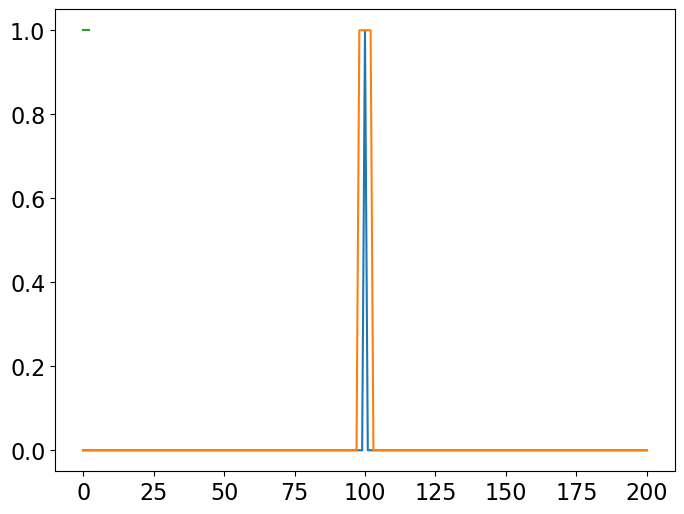

In [11]:
nh, nt = 5, 201
h = np.ones((nt, nh))
H = nonstationary_convmtx(h, nt, hc=nh//2, pad=(nt, nt))
Hsp = nonstationary_convmtx(h, nt, hc=nh//2, sparse=True)
print(Hsp)

x = np.zeros(nt)
x[nt//2] = 1

y = H @ x
ysp = Hsp @ x

plt.figure()
plt.plot(x)
plt.plot(y)
plt.plot(ysp);

In [12]:
nh, nt = 5, 5001
h = np.ones((nt, nh))
H = nonstationary_convmtx(h, nt, hc=nh//2, pad=(nt, nt))
Hsp = nonstationary_convmtx(h, nt, hc=nh//2, sparse=True)
print(H[0])
print(Hsp)

x = np.zeros(nt)
x[nt//2] = 1

%timeit -n 5 -r 4 H @ x
%timeit -n 5 -r 4 Hsp @ x

[1. 1. 1. ... 0. 0. 0.]
<DIAgonal sparse matrix of dtype 'float64'
	with 15003 stored elements (5003 diagonals) and shape (3, 5001)>
  Coords	Values
  (2, 0)	1.0
  (1, 0)	1.0
  (2, 1)	1.0
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (0, 1)	1.0
  (1, 2)	1.0
  (2, 3)	1.0
  (0, 2)	1.0
  (1, 3)	1.0
  (2, 4)	1.0
  (0, 3)	1.0
  (1, 4)	1.0
  (2, 5)	1.0
  (0, 4)	1.0
  (1, 5)	1.0
  (2, 6)	1.0
  (0, 5)	1.0
  (1, 6)	1.0
  (2, 7)	1.0
  (0, 6)	1.0
  (1, 7)	1.0
  (2, 8)	1.0
  (0, 7)	1.0
  :	:
  (2, 4993)	1.0
  (0, 4992)	1.0
  (1, 4993)	1.0
  (2, 4994)	1.0
  (0, 4993)	1.0
  (1, 4994)	1.0
  (2, 4995)	1.0
  (0, 4994)	1.0
  (1, 4995)	1.0
  (2, 4996)	1.0
  (0, 4995)	1.0
  (1, 4996)	1.0
  (2, 4997)	1.0
  (0, 4996)	1.0
  (1, 4997)	1.0
  (2, 4998)	1.0
  (0, 4997)	1.0
  (1, 4998)	1.0
  (2, 4999)	1.0
  (0, 4998)	1.0
  (1, 4999)	1.0
  (2, 5000)	1.0
  (0, 4999)	1.0
  (1, 5000)	1.0
  (0, 5000)	1.0
10.3 ms ± 2.83 ms per loop (mean ± std. dev. of 4 runs, 5 loops each)
The slowest run took 5.98 times longer than the fa

In [13]:
nh, nt = 25, 5001
h = np.ones((nt, nh))
H = nonstationary_convmtx(h, nt, hc=nh//2, pad=(nt, nt))
Hsp = nonstationary_convmtx(h, nt, hc=nh//2, sparse=True)
print(Hsp)

x = np.zeros(nt)
x[nt//2] = 1

%timeit -n 5 -r 4 H @ x
%timeit -n 5 -r 4 Hsp @ x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 65013 stored elements and shape (13, 5001)>
  Coords	Values
  (0, 0)	1.0
  (0, 1)	1.0
  (0, 2)	1.0
  (0, 3)	1.0
  (0, 4)	1.0
  (0, 5)	1.0
  (0, 6)	1.0
  (0, 7)	1.0
  (0, 8)	1.0
  (0, 9)	1.0
  (0, 10)	1.0
  (0, 11)	1.0
  (0, 12)	1.0
  (0, 13)	1.0
  (0, 14)	1.0
  (0, 15)	1.0
  (0, 16)	1.0
  (0, 17)	1.0
  (0, 18)	1.0
  (0, 19)	1.0
  (0, 20)	1.0
  (0, 21)	1.0
  (0, 22)	1.0
  (0, 23)	1.0
  (0, 24)	1.0
  :	:
  (12, 4976)	1.0
  (12, 4977)	1.0
  (12, 4978)	1.0
  (12, 4979)	1.0
  (12, 4980)	1.0
  (12, 4981)	1.0
  (12, 4982)	1.0
  (12, 4983)	1.0
  (12, 4984)	1.0
  (12, 4985)	1.0
  (12, 4986)	1.0
  (12, 4987)	1.0
  (12, 4988)	1.0
  (12, 4989)	1.0
  (12, 4990)	1.0
  (12, 4991)	1.0
  (12, 4992)	1.0
  (12, 4993)	1.0
  (12, 4994)	1.0
  (12, 4995)	1.0
  (12, 4996)	1.0
  (12, 4997)	1.0
  (12, 4998)	1.0
  (12, 4999)	1.0
  (12, 5000)	1.0
8.48 ms ± 2.65 ms per loop (mean ± std. dev. of 4 runs, 5 loops each)
The slowest run took 4.13 times longe